In [9]:
import io
import os
from typing import Optional

import boto3
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


def make_s3_client():
    load_dotenv()

    return boto3.client(
        "s3",
        endpoint_url=os.getenv("YC_ENDPOINT"),
        region_name=os.getenv("YC_REGION"),
        aws_access_key_id=os.getenv("YC_ACCESS_KEY_ID"),
        aws_secret_access_key=os.getenv("YC_SECRET_ACCESS_KEY"),
    )


In [10]:
BUCKET = "binance-data-downloader"
FEATURES_PREFIX = "features"
FEATURE_NAME = "return_1m_forward"
SYMBOL = "ADAUSDT"
INTERVAL = "1m"


def list_return_feature_keys(
    symbol: str = SYMBOL,
    bucket: str = BUCKET,
    features_prefix: str = FEATURES_PREFIX,
    feature_name: str = FEATURE_NAME,
    interval: str = INTERVAL,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    s3_client=None,
) -> list[str]:
    s3 = s3_client or make_s3_client()
    prefix = f"{features_prefix.strip('/')}/{feature_name}/symbol={symbol}/interval={interval}/"

    keys = []
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if not key.endswith("/data.parquet"):
                continue

            date = key.split("/date=", 1)[1].split("/", 1)[0]
            if start_date is not None and date < start_date:
                continue
            if end_date is not None and date > end_date:
                continue
            keys.append(key)

    return sorted(keys)


def load_return_features(
    symbol: str = SYMBOL,
    bucket: str = BUCKET,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    s3_client=None,
) -> pd.DataFrame:
    s3 = s3_client or make_s3_client()
    keys = list_return_feature_keys(
        symbol=symbol,
        bucket=bucket,
        start_date=start_date,
        end_date=end_date,
        s3_client=s3,
    )

    if not keys:
        raise FileNotFoundError(f"No feature parquet files found for {symbol}")

    frames = []
    for key in keys:
        obj = s3.get_object(Bucket=bucket, Key=key)
        frames.append(pd.read_parquet(io.BytesIO(obj["Body"].read())))

    return (
        pd.concat(frames, ignore_index=True)
        .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


s3 = make_s3_client()
ada_returns = load_return_features(SYMBOL, s3_client=s3)

print(ada_returns.shape)
display(ada_returns.head())
display(ada_returns.tail())
display(ada_returns["return_1m"].describe())


(3157918, 4)


,date,symbol,timestamp,return_1m
0,2020-02-01,ADAUSDT,2020-02-01 00:01:00+00:00,-0.000743
1,2020-02-01,ADAUSDT,2020-02-01 00:02:00+00:00,0.000186
2,2020-02-01,ADAUSDT,2020-02-01 00:03:00+00:00,-0.001859
3,2020-02-01,ADAUSDT,2020-02-01 00:04:00+00:00,-0.000745
4,2020-02-01,ADAUSDT,2020-02-01 00:05:00+00:00,0.000932


,date,symbol,timestamp,return_1m
3157913,2026-02-01,ADAUSDT,2026-02-01 23:54:00+00:00,0.000350
3157914,2026-02-01,ADAUSDT,2026-02-01 23:55:00+00:00,0.000701
3157915,2026-02-01,ADAUSDT,2026-02-01 23:56:00+00:00,0.001400
3157916,2026-02-01,ADAUSDT,2026-02-01 23:57:00+00:00,-0.002097
3157917,2026-02-01,ADAUSDT,2026-02-01 23:58:00+00:00,0.000350


count    3.157918e+06
mean     1.788309e-06
std      1.585679e-03
min     -2.188513e-01
25%     -5.964731e-04
50%      0.000000e+00
75%      5.968765e-04
max      1.738054e-01
Name: return_1m, dtype: float64

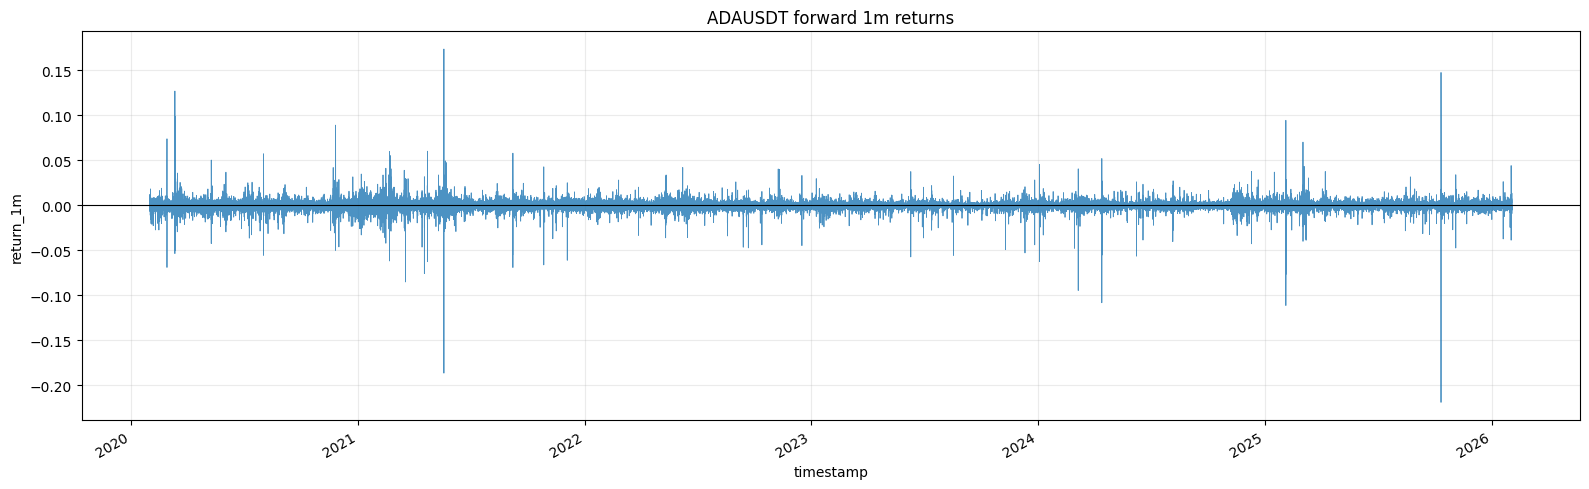

In [3]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    ada_returns["timestamp"],
    ada_returns["return_1m"],
    linewidth=0.6,
    alpha=0.8,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{SYMBOL} forward 1m returns")
ax.set_xlabel("timestamp")
ax.set_ylabel("return_1m")
ax.grid(True, alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("adausdt_return_1m_forward.png", dpi=150)
plt.show()


In [6]:
N_MINUTES = 15


def build_forward_return_n_minutes_from_1m(
    returns_1m: pd.DataFrame,
    n_minutes: int,
    timestamp_col: str = "timestamp",
    return_col: str = "return_1m",
) -> pd.DataFrame:
    """Build t -> t+n minute returns from forward 1-minute returns.

    The input must contain forward returns from t to t+1 minute. The function
    keeps only windows with exactly n consecutive 1-minute returns, so day
    boundaries are preserved when the next day is present and only the final
    impossible rows of the last available day are dropped.
    """
    if n_minutes <= 0:
        raise ValueError("n_minutes must be positive")

    df = (
        returns_1m[[timestamp_col, return_col]]
        .dropna(subset=[timestamp_col, return_col])
        .assign(**{timestamp_col: lambda x: pd.to_datetime(x[timestamp_col], utc=True)})
        .drop_duplicates(subset=[timestamp_col])
        .sort_values(timestamp_col)
        .reset_index(drop=True)
    )

    if df.empty:
        return pd.DataFrame(columns=[timestamp_col, f"return_{n_minutes}m"])

    one_minute = pd.Timedelta(minutes=1)
    group_id = df[timestamp_col].diff().ne(one_minute).cumsum()
    gross_return = 1.0 + df[return_col].astype("float64")

    n_return_col = f"return_{n_minutes}m"
    df[n_return_col] = (
        gross_return
        .groupby(group_id)
        .rolling(n_minutes, min_periods=n_minutes)
        .apply(lambda x: x.prod(), raw=True)
        .reset_index(level=0, drop=True)
        .shift(-(n_minutes - 1))
        - 1.0
    )

    last_window_timestamp = df[timestamp_col].shift(-(n_minutes - 1))
    has_full_window = last_window_timestamp.sub(df[timestamp_col]).eq(
        pd.Timedelta(minutes=n_minutes - 1)
    )

    return (
        df.loc[has_full_window & df[n_return_col].notna(), [timestamp_col, n_return_col]]
        .reset_index(drop=True)
    )





In [ ]:
ada_returns_n = build_forward_return_n_minutes_from_1m(ada_returns, N_MINUTES)

print(ada_returns_n.shape)
display(ada_returns_n.head())
display(ada_returns_n.tail())
display(ada_returns_n[f"return_{N_MINUTES}m"].describe())

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    ada_returns_n["timestamp"],
    ada_returns_n[f"return_{N_MINUTES}m"],
    linewidth=0.6,
    alpha=0.8,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{SYMBOL} forward {N_MINUTES}m returns")
ax.set_xlabel("timestamp")
ax.set_ylabel(f"return_{N_MINUTES}m")
ax.grid(True, alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(f"adausdt_return_{N_MINUTES}m_forward.png", dpi=150)
plt.show()

In [10]:
ada_returns[ada_returns["return_1m"] > 0.002][["timestamp", "return_1m"]]

,timestamp,return_1m
8,2020-02-01 00:09:00+00:00,0.002233
39,2020-02-01 00:40:00+00:00,0.002408
54,2020-02-01 00:55:00+00:00,0.002405
57,2020-02-01 00:58:00+00:00,0.003513
58,2020-02-01 00:59:00+00:00,0.002211
...,...,...
3157881,2026-02-01 23:22:00+00:00,0.007057
3157883,2026-02-01 23:24:00+00:00,0.008436
3157890,2026-02-01 23:31:00+00:00,0.002446
3157891,2026-02-01 23:32:00+00:00,0.004183


In [16]:
RETURN_HORIZONS_MINUTES = [13, 14]
OUTPUT_DIR = "ada_returns_horizons"

os.makedirs(OUTPUT_DIR, exist_ok=True)

horizon_frames = []
saved_files = []

for horizon in RETURN_HORIZONS_MINUTES:
    horizon_df = build_forward_return_n_minutes_from_1m(ada_returns, horizon)
    return_col = f"return_{horizon}m"
    horizon_df.insert(0, "symbol", SYMBOL)

    output_path = os.path.join(OUTPUT_DIR, f"{SYMBOL.lower()}_{return_col}_forward.parquet")
    horizon_df.to_parquet(output_path, index=False, engine="pyarrow", compression="zstd")

    saved_files.append({
        "horizon_minutes": horizon,
        "rows": len(horizon_df),
        "path": output_path,
    })
    horizon_frames.append(horizon_df[["timestamp", return_col]])

ada_returns_horizons = horizon_frames[0]
for horizon_df in horizon_frames[1:]:
    ada_returns_horizons = ada_returns_horizons.merge(horizon_df, on="timestamp", how="outer")

ada_returns_horizons = ada_returns_horizons.sort_values("timestamp").reset_index(drop=True)

saved_files_df = pd.DataFrame(saved_files)
display(ada_returns_horizons.head())
display(ada_returns_horizons.tail())
display(saved_files_df)


,timestamp,return_13m,return_14m
0,2020-02-01 00:01:00+00:00,0.002973,0.002044
1,2020-02-01 00:02:00+00:00,0.002790,0.002976
2,2020-02-01 00:03:00+00:00,0.002789,0.001859
3,2020-02-01 00:04:00+00:00,0.003726,0.003912
4,2020-02-01 00:05:00+00:00,0.004661,0.005593


,timestamp,return_13m,return_14m
3157901,2026-02-01 23:42:00+00:00,-0.009025,-0.008330
3157902,2026-02-01 23:43:00+00:00,-0.009018,-0.007631
3157903,2026-02-01 23:44:00+00:00,-0.007287,-0.009368
3157904,2026-02-01 23:45:00+00:00,-0.006611,-0.006263
3157905,2026-02-01 23:46:00+00:00,-0.007299,NaN


,horizon_minutes,rows,path
0,13,3157906,ada_returns_horizons\adausdt_return_13m_forwar...
1,14,3157905,ada_returns_horizons\adausdt_return_14m_forwar...


In [ ]:
def plot_returns_df(
    returns_df: pd.DataFrame,
    return_cols: Optional[list[str]] = None,
    timestamp_col: str = "timestamp",
    title: Optional[str] = None,
    output_path: Optional[str] = None,
    figsize: tuple[int, int] = (16, 5),
):
    """Plot each return column from a returns DataFrame as a separate chart."""
    if timestamp_col not in returns_df.columns:
        raise ValueError(f"Missing timestamp column: {timestamp_col}")

    if return_cols is None:
        return_cols = [col for col in returns_df.columns if col.startswith("return_")]

    if not return_cols:
        raise ValueError("No return columns found. Pass return_cols explicitly.")

    missing_cols = [col for col in return_cols if col not in returns_df.columns]
    if missing_cols:
        raise ValueError(f"Missing return columns: {missing_cols}")

    plot_df = (
        returns_df[[timestamp_col, *return_cols]]
        .assign(**{timestamp_col: lambda x: pd.to_datetime(x[timestamp_col], utc=True)})
        .sort_values(timestamp_col)
        .reset_index(drop=True)
    )

    figures = []
    for col in return_cols:
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(plot_df[timestamp_col], plot_df[col], linewidth=0.6, alpha=0.85)

        chart_title = f"{title}: {col}" if title else col
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(chart_title)
        ax.set_xlabel(timestamp_col)
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.25)

        fig.autofmt_xdate()
        fig.tight_layout()

        if output_path is not None:
            root, ext = os.path.splitext(output_path)
            ext = ext or ".png"
            fig.savefig(f"{root}_{col}{ext}", dpi=150)

        plt.show()
        figures.append((fig, ax))

    return figures


plot_returns_df(
    ada_returns_horizons,
    title=f"{SYMBOL} forward returns by horizon",
    output_path="adausdt_forward_returns_horizon.png",
)


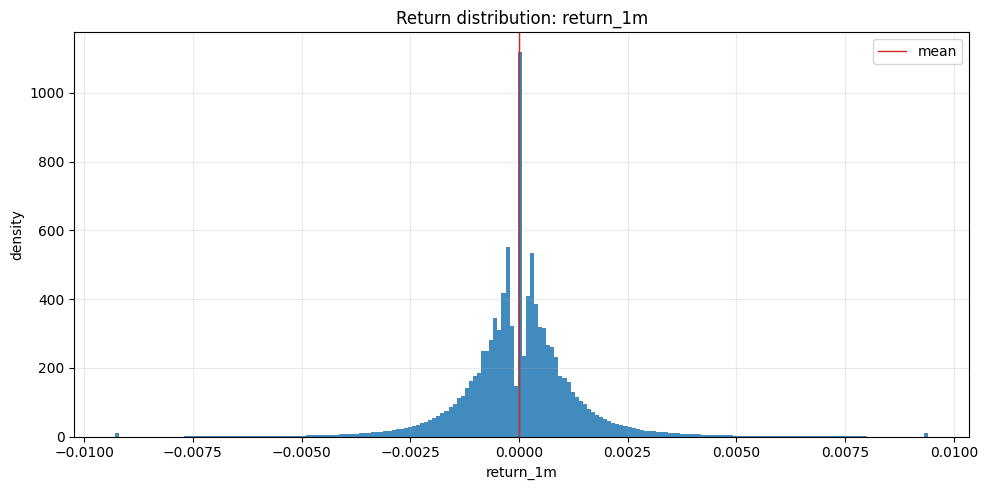

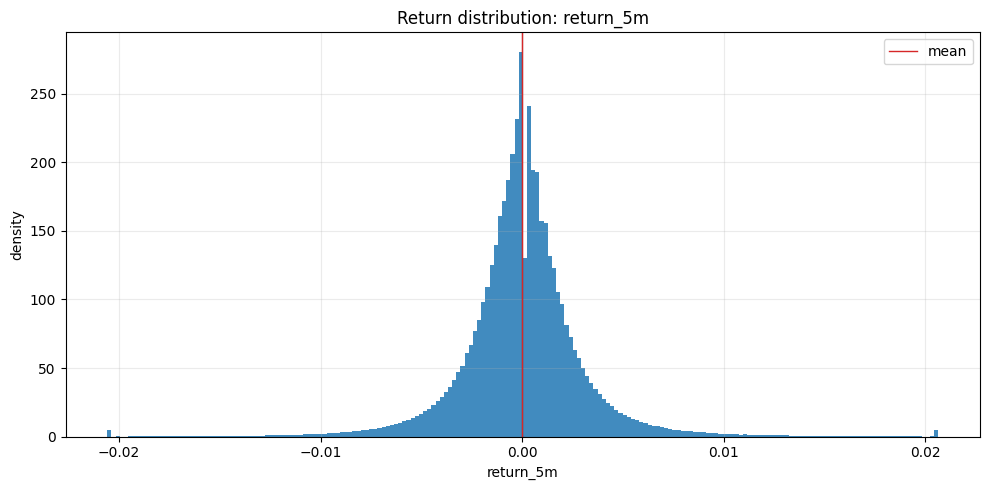

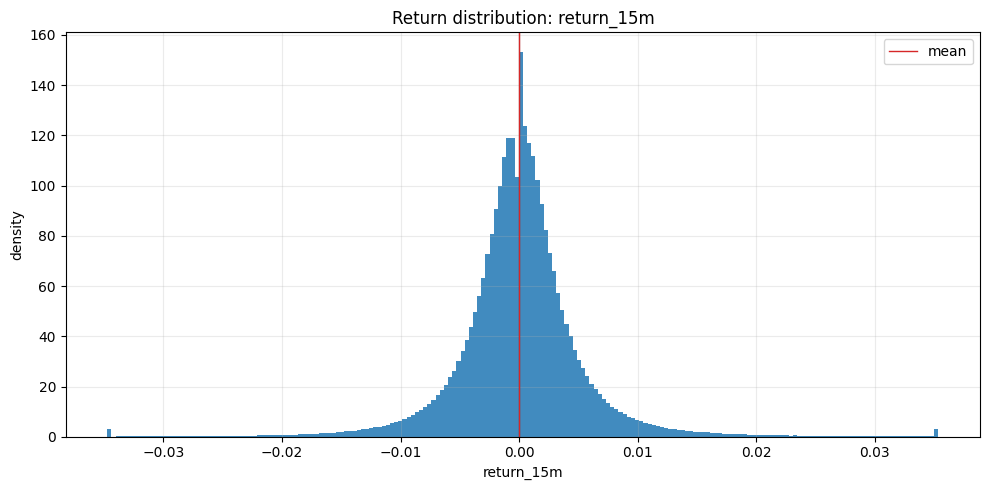

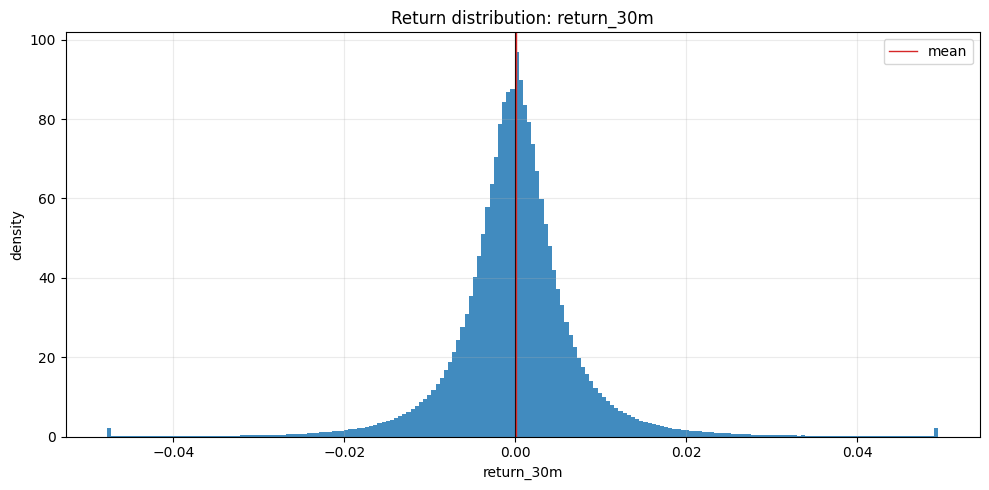

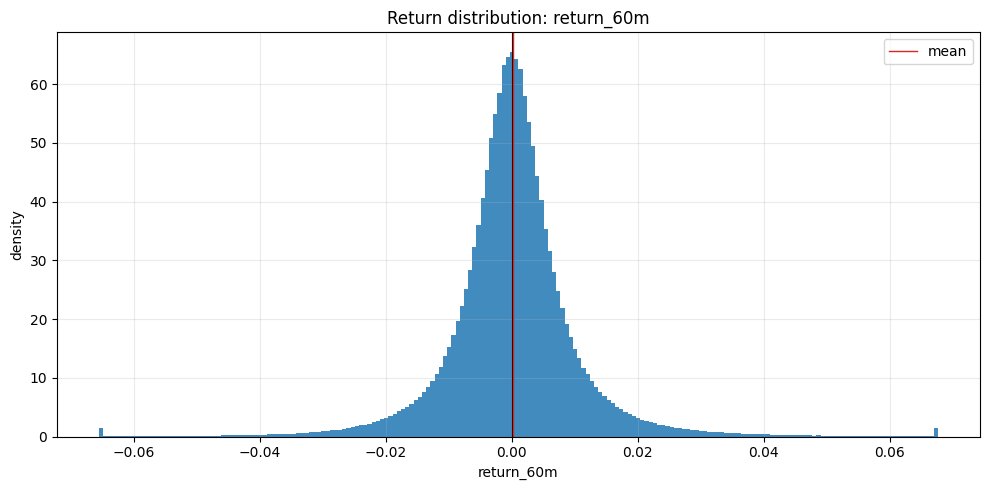

,return_col,count,mean,std,min,clip_left,clip_right,max
0,return_1m,3157918,0.000002,0.001586,-0.218851,-0.009288,0.009417,0.173805
1,return_5m,3157914,0.000009,0.003500,-0.561867,-0.020592,0.020668,0.453593
2,return_15m,3157904,0.000026,0.005909,-0.617594,-0.034721,0.035355,0.811484
3,return_30m,3157889,0.000050,0.008207,-0.639124,-0.047747,0.049503,1.205489
4,return_60m,3157859,0.000096,0.011310,-0.641182,-0.065616,0.067685,1.136150


In [28]:
def plot_return_distributions(
    returns_df: pd.DataFrame,
    return_cols: Optional[list[str]] = None,
    bins: int = 200,
    clip_quantiles: tuple[float, float] = (0.001, 0.999),
    title_prefix: str = "Return distribution",
    output_dir: Optional[str] = "ada_return_distributions",
    figsize: tuple[int, int] = (10, 5),
):
    if return_cols is None:
        return_cols = [col for col in returns_df.columns if col.startswith("return_")]

    if not return_cols:
        raise ValueError("No return columns found. Pass return_cols explicitly.")

    missing_cols = [col for col in return_cols if col not in returns_df.columns]
    if missing_cols:
        raise ValueError(f"Missing return columns: {missing_cols}")

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)

    figures = []
    stats = []

    for col in return_cols:
        series = returns_df[col].dropna().astype("float64")
        if series.empty:
            continue

        left_q, right_q = series.quantile(clip_quantiles).to_list()
        clipped = series.clip(left_q, right_q)

        fig, ax = plt.subplots(figsize=figsize)
        ax.hist(clipped, bins=bins, density=True, alpha=0.85)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.axvline(series.mean(), color="tab:red", linewidth=1.0, label="mean")
        ax.set_title(f"{title_prefix}: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("density")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")
        fig.tight_layout()

        if output_dir is not None:
            fig.savefig(os.path.join(output_dir, f"{SYMBOL.lower()}_{col}_distribution.png"), dpi=150)

        plt.show()
        figures.append((fig, ax))
        stats.append({
            "return_col": col,
            "count": len(series),
            "mean": series.mean(),
            "std": series.std(),
            "min": series.min(),
            "clip_left": left_q,
            "clip_right": right_q,
            "max": series.max(),
        })

    return figures, pd.DataFrame(stats)


distribution_figures, distribution_stats = plot_return_distributions(ada_returns_horizons)
display(distribution_stats)


In [2]:
import pandas as pd
df_1m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_1m_forward.parquet", engine="pyarrow")
df_5m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_5m_forward.parquet", engine="pyarrow")
df_15m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_15m_forward.parquet", engine="pyarrow")
df_30m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_30m_forward.parquet", engine="pyarrow")
df_60m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_60m_forward.parquet", engine="pyarrow")

In [12]:
df_8m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_8m_forward.parquet", engine="pyarrow")
df_10m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_10m_forward.parquet", engine="pyarrow")
df_12m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_12m_forward.parquet", engine="pyarrow")
df_18m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_18m_forward.parquet", engine="pyarrow")
df_20m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_20m_forward.parquet", engine="pyarrow")
df_22m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_22m_forward.parquet", engine="pyarrow")
df_25m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_25m_forward.parquet", engine="pyarrow")
df_28m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_28m_forward.parquet", engine="pyarrow")

In [17]:
df_13m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_13m_forward.parquet", engine="pyarrow")
df_14m = pd.read_parquet(r"C:\projects\binance-dowloader-3.0\ada_returns_horizons\adausdt_return_14m_forward.parquet", engine="pyarrow")

In [ ]:
df_1m.describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]).style.format("{:.10f}")

In [18]:
return_frames = {
    "13m": (df_13m, "return_13m"),
    "14m": (df_14m, "return_14m"),
}

rows = []
for horizon, (df, return_col) in return_frames.items():
    returns = df[return_col].dropna().astype("float64")
    total = len(returns)
    rows.append({
        "horizon": horizon,
        "total": total,
        "p_return_>=_2%": (returns >= 0.02).sum() / total,
        "p_return_>=_1%": (returns >= 0.01).sum() / total,
        "p_return_>=_0.5%": (returns >= 0.005).sum() / total,
        "p_return_<_0.5%": (returns < 0.005).sum() / total,
    })

return_probabilities = pd.DataFrame(rows).set_index("horizon")
return_probabilities.style.format({
    "total": "{:,.0f}",
    "p_return_>=_2%": "{:.4%}",
    "p_return_>=_1%": "{:.4%}",
    "p_return_>=_0.5%": "{:.4%}",
    "p_return_<_0.5%": "{:.4%}",
})

,total,p_return_>=_2%,p_return_>=_1%,p_return_>=_0.5%,p_return_<_0.5%
horizon,,,,,
13m,"3,157,906",0.4614%,2.6119%,9.6166%,90.3834%
14m,"3,157,905",0.5127%,2.8340%,10.1473%,89.8527%


In [19]:
import os

OPPORTUNITIES_OUTPUT_DIR = "ada_trading_opportunities"
os.makedirs(OPPORTUNITIES_OUTPUT_DIR, exist_ok=True)

thresholds_pct = [0.5, 1, 1.5, 2]
return_frames = {
    "13m": (df_13m, "return_13m", 13),
    "14m": (df_14m, "return_14m", 14),
}


def find_independent_opportunities(
    df: pd.DataFrame,
    return_col: str,
    horizon_minutes: int,
    threshold_pct: float,
    timestamp_col: str = "timestamp",
) -> pd.DataFrame:
    threshold = threshold_pct / 100
    opportunity_cols = [
        "timestamp",
        "return",
        "direction",
        "threshold_pct",
        "horizon_minutes",
        "return_col",
    ]
    data = (
        df[[timestamp_col, return_col]]
        .dropna(subset=[timestamp_col, return_col])
        .assign(**{timestamp_col: lambda x: pd.to_datetime(x[timestamp_col], utc=True)})
        .sort_values(timestamp_col)
        .reset_index(drop=True)
    )

    opportunities = []
    cooldown_until = pd.Timestamp.min.tz_localize("UTC")

    for timestamp, return_value in data[[timestamp_col, return_col]].itertuples(index=False, name=None):
        if timestamp <= cooldown_until:
            continue

        if return_value >= threshold:
            direction = "up"
        elif return_value <= -threshold:
            direction = "down"
        else:
            continue

        opportunities.append({
            "timestamp": timestamp,
            "return": float(return_value),
            "direction": direction,
            "threshold_pct": threshold_pct,
            "horizon_minutes": horizon_minutes,
            "return_col": return_col,
        })
        cooldown_until = timestamp + pd.Timedelta(minutes=horizon_minutes)

    return pd.DataFrame(opportunities, columns=opportunity_cols)


summary_rows = []
opportunity_frames = []

for horizon, (df, return_col, horizon_minutes) in return_frames.items():
    for threshold_pct in thresholds_pct:
        opportunities = find_independent_opportunities(
            df=df,
            return_col=return_col,
            horizon_minutes=horizon_minutes,
            threshold_pct=threshold_pct,
        )

        threshold_label = str(threshold_pct).replace(".", "p")
        output_base = os.path.join(
            OPPORTUNITIES_OUTPUT_DIR,
            f"adausdt_{horizon}_threshold_{threshold_label}pct_opportunities",
        )
        opportunities.to_parquet(f"{output_base}.parquet", index=False)
        opportunities.to_csv(f"{output_base}.csv", index=False)

        up_count = int((opportunities["direction"] == "up").sum()) if not opportunities.empty else 0
        down_count = int((opportunities["direction"] == "down").sum()) if not opportunities.empty else 0
        summary_rows.append({
            "horizon": horizon,
            "threshold_pct": threshold_pct,
            "up_count": up_count,
            "down_count": down_count,
            "total_count": up_count + down_count,
            "file_parquet": f"{output_base}.parquet",
            "file_csv": f"{output_base}.csv",
        })

        if not opportunities.empty:
            opportunity_frames.append(opportunities.assign(horizon=horizon))

opportunity_summary = pd.DataFrame(summary_rows)
opportunity_summary.to_csv(
    os.path.join(OPPORTUNITIES_OUTPUT_DIR, "adausdt_opportunity_summary.csv"),
    index=False,
)

if opportunity_frames:
    all_opportunities = pd.concat(opportunity_frames, ignore_index=True)
else:
    all_opportunities = pd.DataFrame()

display(opportunity_summary)


,horizon,threshold_pct,up_count,down_count,total_count,file_parquet,file_csv
0,13m,0.5,45502,45060,90562,ada_trading_opportunities\adausdt_13m_threshol...,ada_trading_opportunities\adausdt_13m_threshol...
1,13m,1.0,14448,14165,28613,ada_trading_opportunities\adausdt_13m_threshol...,ada_trading_opportunities\adausdt_13m_threshol...
2,13m,1.5,5931,5680,11611,ada_trading_opportunities\adausdt_13m_threshol...,ada_trading_opportunities\adausdt_13m_threshol...
3,13m,2.0,2858,2674,5532,ada_trading_opportunities\adausdt_13m_threshol...,ada_trading_opportunities\adausdt_13m_threshol...
4,14m,0.5,44504,44505,89009,ada_trading_opportunities\adausdt_14m_threshol...,ada_trading_opportunities\adausdt_14m_threshol...
5,14m,1.0,14569,14384,28953,ada_trading_opportunities\adausdt_14m_threshol...,ada_trading_opportunities\adausdt_14m_threshol...
6,14m,1.5,6104,5871,11975,ada_trading_opportunities\adausdt_14m_threshol...,ada_trading_opportunities\adausdt_14m_threshol...
7,14m,2.0,2989,2778,5767,ada_trading_opportunities\adausdt_14m_threshol...,ada_trading_opportunities\adausdt_14m_threshol...


In [ ]:
OPPORTUNITY_PLOTS_DIR = "ada_trading_opportunity_plots"
os.makedirs(OPPORTUNITY_PLOTS_DIR, exist_ok=True)

plot_horizons = [5, 15, 22, 30]
plot_threshold_pct = 1
cluster_freq = "7D"


def format_minutes_ru(minutes: int) -> str:
    if 11 <= minutes % 100 <= 14:
        word = "минут"
    elif minutes % 10 == 1:
        word = "минута"
    elif 2 <= minutes % 10 <= 4:
        word = "минуты"
    else:
        word = "минут"
    return f"{minutes} {word}"


def load_opportunities_for_plot(horizon_minutes: int, threshold_pct: float) -> pd.DataFrame:
    threshold_label = str(threshold_pct).replace(".", "p")
    if threshold_label.endswith("p0"):
        threshold_label = threshold_label[:-2]

    path = os.path.join(
        OPPORTUNITIES_OUTPUT_DIR,
        f"adausdt_{horizon_minutes}m_threshold_{threshold_label}pct_opportunities.parquet",
    )
    opportunities = pd.read_parquet(path)
    return opportunities.assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))


opportunity_cluster_stats = []

for horizon_minutes in plot_horizons:
    horizon_label = format_minutes_ru(horizon_minutes)
    opportunities = load_opportunities_for_plot(horizon_minutes, plot_threshold_pct)
    opportunities = opportunities.sort_values("timestamp").reset_index(drop=True)

    weekly_counts = (
        opportunities
        .set_index("timestamp")
        .resample(cluster_freq)
        .size()
        .rename("Количество возможностей")
        .reset_index()
    )

    up_count = int((opportunities["direction"] == "up").sum())
    down_count = int((opportunities["direction"] == "down").sum())

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(
        weekly_counts["timestamp"],
        weekly_counts["Количество возможностей"],
        width=6,
        alpha=0.85,
    )
    ax.set_title(
        f"ADAUSDT: плотность торговых возможностей от 1% за {horizon_label} "
        f"(рост: {up_count:,}, падение: {down_count:,}, всего: {len(opportunities):,})"
    )
    ax.set_xlabel("Дата")
    ax.set_ylabel("Количество возможностей за 7 дней")
    ax.grid(True, axis="y", alpha=0.25)

    fig.tight_layout()
    output_path = os.path.join(
        OPPORTUNITY_PLOTS_DIR,
        f"adausdt_{horizon_minutes}m_threshold_1pct_opportunity_clusters.png",
    )
    fig.savefig(output_path, dpi=150)
    plt.show()

    opportunity_cluster_stats.append({
        "Интервал": horizon_label,
        "Порог доходности, %": plot_threshold_pct,
        "Ростов": up_count,
        "Падений": down_count,
        "Всего возможностей": len(opportunities),
        "Максимум возможностей за 7 дней": int(weekly_counts["Количество возможностей"].max()),
        "Файл графика": output_path,
    })

opportunity_cluster_stats = pd.DataFrame(opportunity_cluster_stats)
display(opportunity_cluster_stats)


In [22]:
import re
from pathlib import Path

PERIOD_START = pd.Timestamp("2025-07-01", tz="UTC")
RETURN_HORIZONS_DIR = Path("ada_returns_horizons")
OPPORTUNITIES_2025_H2_DIR = Path("ada_trading_opportunities_2025_h2")
OPPORTUNITIES_2025_H2_DIR.mkdir(exist_ok=True)

thresholds_pct = [0.5, 1, 1.5, 2]
opportunity_cols = [
    "timestamp",
    "return",
    "direction",
    "threshold_pct",
    "horizon_minutes",
    "return_col",
]


def parse_horizon_from_return_path(path: Path) -> int:
    match = re.search(r"return_(\d+)m_forward", path.name)
    if match is None:
        raise ValueError(f"Cannot parse horizon from {path}")
    return int(match.group(1))


def find_independent_opportunities_in_period(
    returns: pd.DataFrame,
    return_col: str,
    horizon_minutes: int,
    threshold_pct: float,
    timestamp_col: str = "timestamp",
) -> pd.DataFrame:
    threshold = threshold_pct / 100
    opportunities = []
    cooldown_until = pd.Timestamp.min.tz_localize("UTC")

    for timestamp, return_value in returns[[timestamp_col, return_col]].itertuples(index=False, name=None):
        if timestamp <= cooldown_until:
            continue

        if return_value >= threshold:
            direction = "up"
        elif return_value <= -threshold:
            direction = "down"
        else:
            continue

        opportunities.append({
            "timestamp": timestamp,
            "return": float(return_value),
            "direction": direction,
            "threshold_pct": threshold_pct,
            "horizon_minutes": horizon_minutes,
            "return_col": return_col,
        })
        cooldown_until = timestamp + pd.Timedelta(minutes=horizon_minutes)

    return pd.DataFrame(opportunities, columns=opportunity_cols)


return_paths = sorted(
    RETURN_HORIZONS_DIR.glob("adausdt_return_*m_forward.parquet"),
    key=parse_horizon_from_return_path,
)

summary_rows = []

for path in return_paths:
    horizon_minutes = parse_horizon_from_return_path(path)
    horizon = f"{horizon_minutes}m"
    return_col = f"return_{horizon}"

    returns = pd.read_parquet(path, columns=["timestamp", return_col])
    returns = (
        returns
        .dropna(subset=["timestamp", return_col])
        .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
        .loc[lambda x: x["timestamp"] >= PERIOD_START]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    data_start = returns["timestamp"].min() if not returns.empty else pd.NaT
    data_end = returns["timestamp"].max() if not returns.empty else pd.NaT

    for threshold_pct in thresholds_pct:
        opportunities = find_independent_opportunities_in_period(
            returns=returns,
            return_col=return_col,
            horizon_minutes=horizon_minutes,
            threshold_pct=threshold_pct,
        )

        threshold_label = str(threshold_pct).replace(".", "p")
        output_base = OPPORTUNITIES_2025_H2_DIR / f"adausdt_{horizon}_threshold_{threshold_label}pct_opportunities_2025_h2"
        opportunities.to_parquet(f"{output_base}.parquet", index=False)
        opportunities.to_csv(f"{output_base}.csv", index=False)

        up_count = int((opportunities["direction"] == "up").sum())
        down_count = int((opportunities["direction"] == "down").sum())
        summary_rows.append({
            "horizon": horizon,
            "horizon_minutes": horizon_minutes,
            "threshold_pct": threshold_pct,
            "period_start": data_start,
            "period_end": data_end,
            "total_return_rows": len(returns),
            "up_count": up_count,
            "down_count": down_count,
            "total_count": up_count + down_count,
            "file_parquet": f"{output_base}.parquet",
            "file_csv": f"{output_base}.csv",
        })

opportunity_summary_2025_h2 = pd.DataFrame(summary_rows)
opportunity_summary_2025_h2 = opportunity_summary_2025_h2.sort_values(["horizon_minutes", "threshold_pct"]).reset_index(drop=True)
opportunity_summary_2025_h2.to_csv(
    OPPORTUNITIES_2025_H2_DIR / "adausdt_opportunity_summary_2025_h2.csv",
    index=False,
)

display(opportunity_summary_2025_h2)


,horizon,horizon_minutes,threshold_pct,period_start,period_end,total_return_rows,up_count,down_count,total_count,file_parquet,file_csv
0,1m,1,0.5,2025-07-01 00:00:00+00:00,2026-02-01 23:58:00+00:00,311039,656,610,1266,ada_trading_opportunities_2025_h2\adausdt_1m_t...,ada_trading_opportunities_2025_h2\adausdt_1m_t...
1,1m,1,1.0,2025-07-01 00:00:00+00:00,2026-02-01 23:58:00+00:00,311039,74,68,142,ada_trading_opportunities_2025_h2\adausdt_1m_t...,ada_trading_opportunities_2025_h2\adausdt_1m_t...
2,1m,1,1.5,2025-07-01 00:00:00+00:00,2026-02-01 23:58:00+00:00,311039,25,36,61,ada_trading_opportunities_2025_h2\adausdt_1m_t...,ada_trading_opportunities_2025_h2\adausdt_1m_t...
3,1m,1,2.0,2025-07-01 00:00:00+00:00,2026-02-01 23:58:00+00:00,311039,16,25,41,ada_trading_opportunities_2025_h2\adausdt_1m_t...,ada_trading_opportunities_2025_h2\adausdt_1m_t...
4,5m,5,0.5,2025-07-01 00:00:00+00:00,2026-02-01 23:54:00+00:00,311035,3136,3131,6267,ada_trading_opportunities_2025_h2\adausdt_5m_t...,ada_trading_opportunities_2025_h2\adausdt_5m_t...
5,5m,5,1.0,2025-07-01 00:00:00+00:00,2026-02-01 23:54:00+00:00,311035,442,385,827,ada_trading_opportunities_2025_h2\adausdt_5m_t...,ada_trading_opportunities_2025_h2\adausdt_5m_t...
6,5m,5,1.5,2025-07-01 00:00:00+00:00,2026-02-01 23:54:00+00:00,311035,115,101,216,ada_trading_opportunities_2025_h2\adausdt_5m_t...,ada_trading_opportunities_2025_h2\adausdt_5m_t...
7,5m,5,2.0,2025-07-01 00:00:00+00:00,2026-02-01 23:54:00+00:00,311035,43,44,87,ada_trading_opportunities_2025_h2\adausdt_5m_t...,ada_trading_opportunities_2025_h2\adausdt_5m_t...
8,8m,8,0.5,2025-07-01 00:00:00+00:00,2026-02-01 23:51:00+00:00,311032,3712,3763,7475,ada_trading_opportunities_2025_h2\adausdt_8m_t...,ada_trading_opportunities_2025_h2\adausdt_8m_t...
9,8m,8,1.0,2025-07-01 00:00:00+00:00,2026-02-01 23:51:00+00:00,311032,621,604,1225,ada_trading_opportunities_2025_h2\adausdt_8m_t...,ada_trading_opportunities_2025_h2\adausdt_8m_t...
